# Satellite and reanalysis context for a high-risk event

The BA event catalog identifies **2021-02-17 01:00 UTC** as the peak hour of a 33-hour `MISO_SUBREGION_SUM` installed-portfolio net-load event (2021-02-16 22:00 through 2021-02-18 06:00 UTC, P90 threshold).

The panels below connect that catalog event to NASA Worldview MODIS Aqua true-color imagery and NOAA NARR fields near the peak hour: 500 mb height, 2 m temperature, 1000 mb wind, and downward shortwave radiation. They provide broad **weather context**, not a formal weather-regime classification.

**Inputs:** the timestamp below, a NASA Worldview daily snapshot, and NOAA PSL NARR plots. The event catalog is cited above for context; it is not read by this notebook. Satellite imagery uses the UTC date and NARR uses the nearest three-hour timestamp.

**Requirements:** network access to NASA Worldview and NOAA PSL when rerunning. Saved images remain viewable offline.

**Outputs:** five embedded images; no files are written. Requests have a 20-second timeout. If a retrieval fails, the error and source URL identify which panel could not be refreshed.

Run the code cells from top to bottom. See the [setup instructions](../../README.md#quick-start).

## Setup

In [1]:
import re
import ssl
from urllib.parse import urlencode
from urllib.request import Request, urlopen

import certifi
import pandas as pd
from IPython.display import Image, display


REQUEST_HEADERS = {"User-Agent": "Mozilla/5.0"}
SSL_CONTEXT = ssl.create_default_context(cafile=certifi.where())

timestamp_utc = pd.Timestamp("2021-02-17T01:00:00Z").tz_convert("UTC")  # Catalog event peak.
weather_plot_time_utc = timestamp_utc.round("3h")
satellite_time_utc = timestamp_utc.normalize()

print(f"Event peak: {timestamp_utc}; NARR valid time: {weather_plot_time_utc}")

Event peak: 2021-02-17 01:00:00+00:00; NARR valid time: 2021-02-17 00:00:00+00:00


## Step 1: Retrieve the satellite image

Request NASA Worldview imagery for the event's UTC date.

NASA Worldview MODIS Aqua True Color
https://wvs.earthdata.nasa.gov/api/v1/snapshot?REQUEST=GetSnapshot&TIME=2021-02-17T00%3A00%3A00Z&BBOX=24,-130,51,-65&CRS=EPSG%3A4326&LAYERS=MODIS_Aqua_CorrectedReflectance_TrueColor,Coastlines_15m,Reference_Features_15m&WRAP=day,x,x&FORMAT=image%2Fjpeg&WIDTH=1479&HEIGHT=614&colormaps=,,


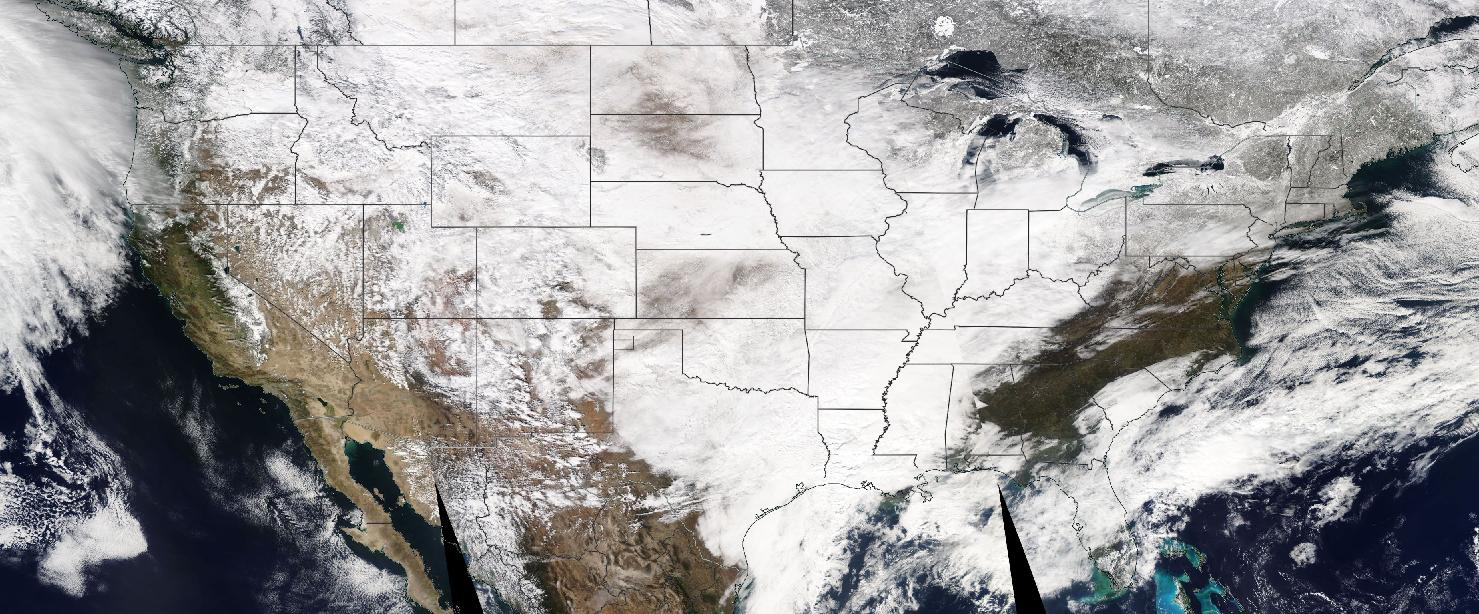

In [2]:
worldview_params = {
    "REQUEST": "GetSnapshot",
    "TIME": satellite_time_utc.strftime("%Y-%m-%dT%H:%M:%SZ"),
    "BBOX": "24,-130,51,-65",
    "CRS": "EPSG:4326",
    "LAYERS": "MODIS_Aqua_CorrectedReflectance_TrueColor,Coastlines_15m,Reference_Features_15m",
    "WRAP": "day,x,x",
    "FORMAT": "image/jpeg",
    "WIDTH": "1479",
    "HEIGHT": "614",
    "colormaps": ",,",
}
worldview_url = "https://wvs.earthdata.nasa.gov/api/v1/snapshot?" + urlencode(
    worldview_params, safe=","
)

print("NASA Worldview MODIS Aqua True Color")
print(worldview_url)
request = Request(worldview_url, headers=REQUEST_HEADERS)
with urlopen(request, timeout=20, context=SSL_CONTEXT) as response:
    display(Image(data=response.read()))

## Step 2: Retrieve the NARR panels

Request the four NOAA NARR panels at the nearest three-hour timestamp. This cell can be rerun independently of the satellite request.

NARR 500 mb Geopotential Height
https://psl.noaa.gov/cgi-bin/data/narr/comp.hour.pl?var=Geopotential+Height&iy%5B1%5D=2021&im%5B1%5D=02&id%5B1%5D=17&ih%5B1%5D=00&resolution=3&proj=US+Lower+48&level=500mb&labels=Shaded+w%2Foverlying+contours&labelcon=1


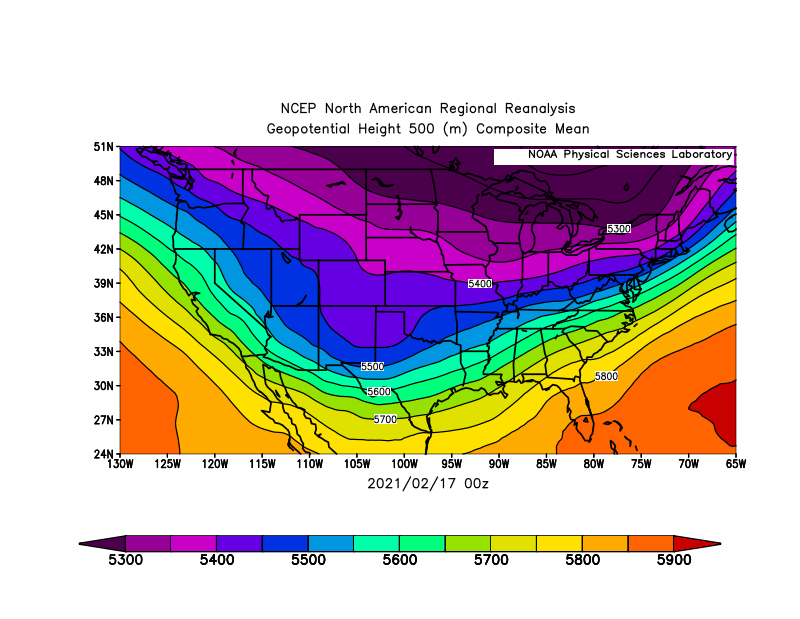

NARR 2m Air Temperature
https://psl.noaa.gov/cgi-bin/data/narr/comp.hour.pl?var=Air+Temperature+at+2m&iy%5B1%5D=2021&im%5B1%5D=02&id%5B1%5D=17&ih%5B1%5D=00&resolution=3&proj=US+Lower+48&labels=Shaded+w%2Foverlying+contours&labelcon=1


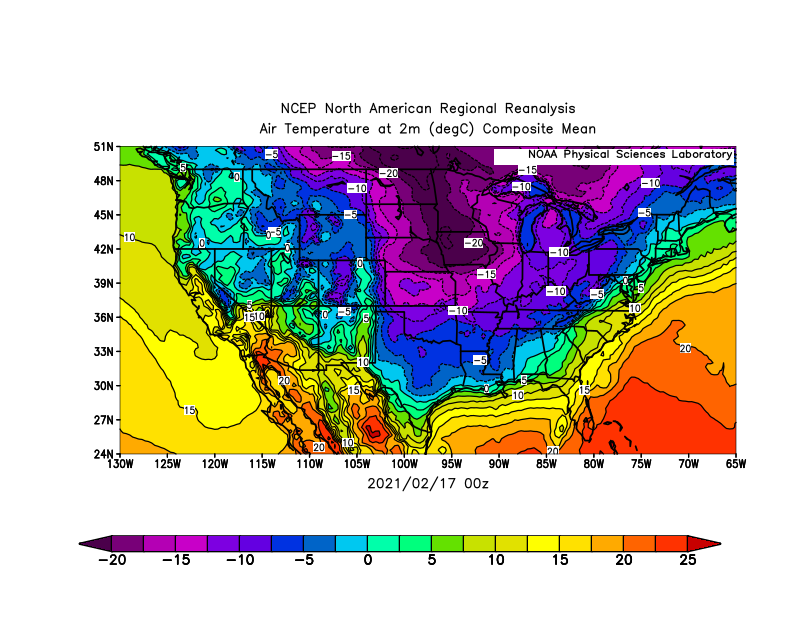

NARR 1000 mb Vector Wind
https://psl.noaa.gov/cgi-bin/data/narr/comp.hour.pl?var=Vector+Wind&iy%5B1%5D=2021&im%5B1%5D=02&id%5B1%5D=17&ih%5B1%5D=00&resolution=3&proj=US+Lower+48&level=1000mb


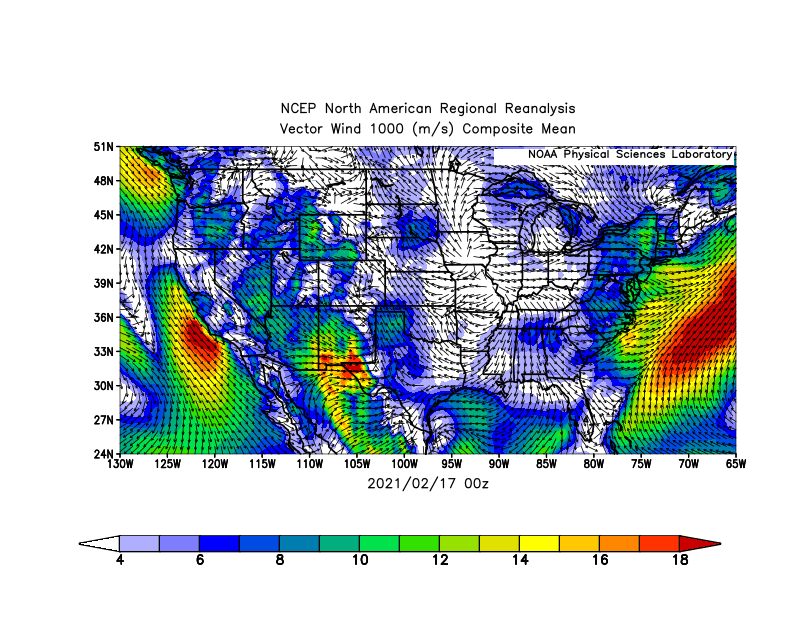

NARR Surface Downward Shortwave Radiation
https://psl.noaa.gov/cgi-bin/data/narr/comp.hour.pl?var=Downward+Shortwave+Radiation+Flux+at+Surface&iy%5B1%5D=2021&im%5B1%5D=02&id%5B1%5D=17&ih%5B1%5D=00&resolution=3&proj=US+Lower+48&labels=Shaded+w%2Foverlying+contours&labelcon=1


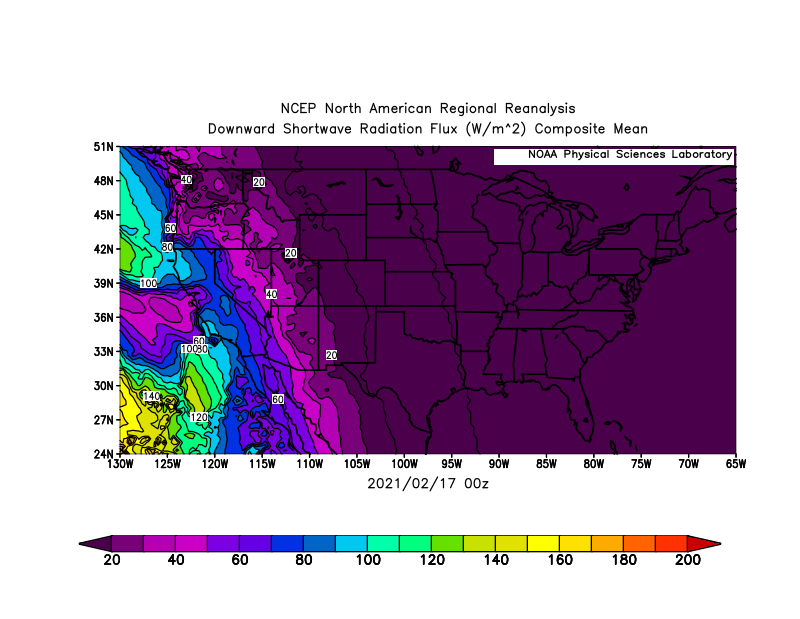

In [3]:
narr_panels = [
    {
        "title": "NARR 500 mb Geopotential Height",
        "variable": "Geopotential Height",
        "level": "500mb",
        "use_shaded_contours": True,
    },
    {
        "title": "NARR 2m Air Temperature",
        "variable": "Air Temperature at 2m",
        "level": None,
        "use_shaded_contours": True,
    },
    {
        "title": "NARR 1000 mb Vector Wind",
        "variable": "Vector Wind",
        "level": "1000mb",
        "use_shaded_contours": False,
    },
    {
        "title": "NARR Surface Downward Shortwave Radiation",
        "variable": "Downward Shortwave Radiation Flux at Surface",
        "level": None,
        "use_shaded_contours": True,
    },
]

for panel in narr_panels:
    psl_params = {
        "var": panel["variable"],
        "iy[1]": weather_plot_time_utc.strftime("%Y"),
        "im[1]": weather_plot_time_utc.strftime("%m"),
        "id[1]": weather_plot_time_utc.strftime("%d"),
        "ih[1]": weather_plot_time_utc.strftime("%H"),
        "resolution": "3",
        "proj": "US Lower 48",
    }
    if panel["level"] is not None:
        psl_params["level"] = panel["level"]
    if panel["use_shaded_contours"]:
        psl_params["labels"] = "Shaded w/overlying contours"
        psl_params["labelcon"] = "1"

    source_url = "https://psl.noaa.gov/cgi-bin/data/narr/comp.hour.pl?" + urlencode(psl_params)
    print(panel["title"])
    print(source_url)

    try:
        request = Request(source_url, headers=REQUEST_HEADERS)
        with urlopen(request, timeout=20, context=SSL_CONTEXT) as response:
            psl_html = response.read().decode("utf-8", errors="replace")

        match = re.search(
            r"""(?P<src>(?:https://psl\.noaa\.gov)?/tmp/narr/[^"']+?\.png)""", psl_html
        )
        if not match:
            print("Temporary PSL PNG was not found; open the source URL above.")
            continue

        temp_png_url = match.group("src")
        if temp_png_url.startswith("/"):
            temp_png_url = "https://psl.noaa.gov" + temp_png_url

        request = Request(temp_png_url, headers=REQUEST_HEADERS)
        with urlopen(request, timeout=20, context=SSL_CONTEXT) as response:
            display(Image(data=response.read()))
    except Exception as error:
        print(f"Could not download {panel['title']}: {error}")
        print("Open the source URL above.")

## Interpretation

Read these panels as weather context around the catalog event. The satellite
image represents the UTC date; the NARR fields represent the nearest three-hour
timestamp. These different sampling times do not establish an hourly weather
classification or a causal explanation of the net-load event.